# Institutional-Style Markowitz Portfolio Optimizer

A complete Google Colab project that downloads market data, cleans and validates it, estimates expected returns and covariance, constructs an efficient frontier, identifies minimum-volatility and maximum-Sharpe portfolios, evaluates out-of-sample performance, and produces professional visualizations.

**Primary use cases:** asset allocation, portfolio construction, risk budgeting, investment research, and quantitative finance recruiting portfolios.

> Educational use only. This notebook is not investment advice.


## 1. Project Overview

The project builds a long-only multi-asset portfolio optimizer using Modern Portfolio Theory. It supports configurable tickers, historical windows, return estimation methods, covariance shrinkage, constraints, transaction-cost-aware rebalancing, Monte Carlo portfolio simulation, deterministic optimization, and out-of-sample backtesting.

### Real-world finance use case
Portfolio managers and research teams use related workflows to convert capital-market assumptions into investable allocations while respecting risk, diversification, liquidity, and mandate constraints. The same mathematical foundation appears in wealth management, ETF allocation, pension portfolios, multi-asset funds, and risk-control overlays.


## 2. System Architecture

1. **Configuration layer** — tickers, dates, constraints, risk-free rate, and model choices.
2. **Data ingestion layer** — Yahoo Finance price history and optional FRED risk-free-rate input.
3. **Data quality layer** — missing data checks, alignment, winsorization, and minimum-history requirements.
4. **Feature layer** — returns, annualized expected returns, covariance, correlation, and rolling risk statistics.
5. **Optimization layer** — minimum variance, maximum Sharpe, target-return portfolios, and efficient frontier.
6. **Backtest layer** — train/test split, benchmark comparison, turnover, and transaction costs.
7. **Presentation layer** — frontier plots, allocation charts, correlation heatmaps, cumulative returns, drawdowns, and summary tables.


## 3. Required APIs and Data Sources

- **Yahoo Finance** via `yfinance`: adjusted daily prices and benchmark history.
- **FRED** via `pandas_datareader` or manual input: optional Treasury-bill risk-free rate.
- Optional upgrades: Polygon, Alpha Vantage, Financial Modeling Prep, or institutional data vendors.


## 4. Install Dependencies

In [2]:
# Colab Cell 1 — Install dependencies
!pip -q install yfinance plotly scikit-learn scipy seaborn


## 5. Imports and Global Configuration

In [3]:
# Colab Cell 2 — Imports and configuration
from __future__ import annotations

import warnings
from dataclasses import dataclass
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid')

TRADING_DAYS = 252

@dataclass(frozen=True)
class Config:
    tickers: Tuple[str, ...] = ('SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'GLD')
    benchmark: str = 'SPY'
    start_date: str = '2018-01-01'
    end_date: Optional[str] = None
    risk_free_rate: float = 0.04
    min_weight: float = 0.00
    max_weight: float = 0.35
    n_frontier_points: int = 40
    n_random_portfolios: int = 15000
    train_fraction: float = 0.70
    transaction_cost_bps: float = 10.0
    use_log_returns: bool = False
    use_covariance_shrinkage: bool = True
    random_seed: int = 42

CONFIG = Config()
CONFIG


Config(tickers=('SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'GLD'), benchmark='SPY', start_date='2018-01-01', end_date=None, risk_free_rate=0.04, min_weight=0.0, max_weight=0.35, n_frontier_points=40, n_random_portfolios=15000, train_fraction=0.7, transaction_cost_bps=10.0, use_log_returns=False, use_covariance_shrinkage=True, random_seed=42)

## 6. Data Collection Pipeline

In [4]:
# Colab Cell 3 — Robust market data downloader

def download_prices(
    tickers: Iterable[str],
    start_date: str,
    end_date: Optional[str] = None,
    min_observations: int = 252,
) -> pd.DataFrame:
    """Download adjusted close prices and apply basic quality controls."""
    ticker_list = sorted(set(tickers))
    if len(ticker_list) < 2:
        raise ValueError('At least two unique tickers are required.')

    try:
        raw = yf.download(
            ticker_list,
            start=start_date,
            end=end_date,
            auto_adjust=True,
            progress=False,
            group_by='column',
            threads=True,
        )
    except Exception as exc:
        raise RuntimeError(f'Yahoo Finance download failed: {exc}') from exc

    if raw is None or raw.empty:
        raise RuntimeError('No market data was returned. Check tickers, dates, or internet access.')

    if isinstance(raw.columns, pd.MultiIndex):
        if 'Close' not in raw.columns.get_level_values(0):
            raise RuntimeError('Expected a Close field in the downloaded data.')
        prices = raw['Close'].copy()
    else:
        prices = raw[['Close']].rename(columns={'Close': ticker_list[0]})

    prices = prices.sort_index().replace([np.inf, -np.inf], np.nan)
    prices = prices.dropna(axis=1, how='all')

    valid_counts = prices.notna().sum()
    invalid = valid_counts[valid_counts < min_observations].index.tolist()
    if invalid:
        print(f'Warning: dropping tickers with fewer than {min_observations} observations: {invalid}')
        prices = prices.drop(columns=invalid)

    prices = prices.ffill(limit=5).dropna(how='any')

    if prices.shape[1] < 2:
        raise RuntimeError('Fewer than two assets remain after data-quality filtering.')
    if prices.shape[0] < min_observations:
        raise RuntimeError('Insufficient aligned history after cleaning.')

    return prices

all_tickers = tuple(sorted(set(CONFIG.tickers + (CONFIG.benchmark,))))
prices = download_prices(all_tickers, CONFIG.start_date, CONFIG.end_date)
asset_prices = prices[list(CONFIG.tickers)]
benchmark_prices = prices[CONFIG.benchmark]

print(f'Dataset shape: {prices.shape[0]:,} rows x {prices.shape[1]} instruments')
display(prices.tail())


Dataset shape: 2,153 rows x 7 instruments


Ticker,EEM,EFA,GLD,IWM,QQQ,SPY,TLT
Date,,,,,,,
2026-07-22,64.9900,104.2500,379.1200,293.7900,705.3500,747.4100,83.4400
2026-07-23,64.6000,102.9000,371.5200,292.0900,691.9600,738.1800,83.1700
2026-07-24,63.3300,102.9000,371.9000,291.1700,684.2300,738.9300,83.2500
2026-07-27,63.6200,103.9100,374.6300,292.9100,682.1200,739.0900,83.7500
2026-07-28,62.3600,103.8900,369.3700,293.3700,675.4900,740.8600,84.2400


## 7. Data Cleaning and Feature Engineering

In [5]:
# Colab Cell 4 — Returns, outlier controls, and train/test split

def compute_returns(prices: pd.DataFrame, use_log_returns: bool = False) -> pd.DataFrame:
    """Compute daily returns and remove extreme bad ticks conservatively."""
    if (prices <= 0).any().any():
        raise ValueError('Prices must be strictly positive.')

    returns = np.log(prices / prices.shift(1)) if use_log_returns else prices.pct_change()
    returns = returns.replace([np.inf, -np.inf], np.nan).dropna(how='any')

    # Winsorize each series at the 0.1% and 99.9% quantiles to reduce bad-tick impact.
    lower = returns.quantile(0.001)
    upper = returns.quantile(0.999)
    returns = returns.clip(lower=lower, upper=upper, axis=1)
    return returns

returns = compute_returns(asset_prices, CONFIG.use_log_returns)
benchmark_returns = compute_returns(benchmark_prices.to_frame(), CONFIG.use_log_returns).iloc[:, 0]

split_idx = int(len(returns) * CONFIG.train_fraction)
if split_idx < 252 or len(returns) - split_idx < 60:
    raise ValueError('Train/test split leaves insufficient history. Expand the date range.')

train_returns = returns.iloc[:split_idx].copy()
test_returns = returns.iloc[split_idx:].copy()

print(f'Train period: {train_returns.index.min().date()} to {train_returns.index.max().date()}')
print(f'Test period:  {test_returns.index.min().date()} to {test_returns.index.max().date()}')
display(train_returns.describe().T)


Train period: 2018-01-03 to 2023-12-27
Test period:  2023-12-28 to 2026-07-28


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
SPY,"1,506.0000",0.0006,0.0125,-0.0751,-0.0050,0.0008,0.0069,0.0827
QQQ,"1,506.0000",0.0008,0.0154,-0.0684,-0.0066,0.0013,0.0090,0.0772
IWM,"1,506.0000",0.0004,0.0157,-0.0943,-0.0079,0.0010,0.0092,0.0751
EFA,"1,506.0000",0.0003,0.0115,-0.0758,-0.0055,0.0007,0.0063,0.0599
EEM,"1,506.0000",0.0001,0.0136,-0.0836,-0.0072,0.0005,0.0078,0.0717
TLT,"1,506.0000",-0.0000,0.0102,-0.0491,-0.0063,0.0001,0.0058,0.0504
GLD,"1,506.0000",0.0003,0.0089,-0.0523,-0.0044,0.0005,0.0051,0.0434


## 8. Core Estimation Models

In [6]:
# Colab Cell 5 — Expected return and covariance estimators

def annualized_mean_returns(daily_returns: pd.DataFrame) -> pd.Series:
    return daily_returns.mean() * TRADING_DAYS


def annualized_covariance(daily_returns: pd.DataFrame, shrinkage: bool = True) -> pd.DataFrame:
    if shrinkage:
        model = LedoitWolf().fit(daily_returns.values)
        cov = pd.DataFrame(model.covariance_, index=daily_returns.columns, columns=daily_returns.columns)
    else:
        cov = daily_returns.cov()
    return cov * TRADING_DAYS

expected_returns = annualized_mean_returns(train_returns)
cov_matrix = annualized_covariance(train_returns, CONFIG.use_covariance_shrinkage)
corr_matrix = train_returns.corr()

summary = pd.DataFrame({
    'Expected Return': expected_returns,
    'Volatility': np.sqrt(np.diag(cov_matrix)),
    'Sharpe': (expected_returns - CONFIG.risk_free_rate) / np.sqrt(np.diag(cov_matrix)),
})
display(summary.sort_values('Sharpe', ascending=False))


,Expected Return,Volatility,Sharpe
Ticker,,,
QQQ,0.2094,0.2447,0.6924
SPY,0.1415,0.1989,0.5100
GLD,0.0815,0.1423,0.2914
IWM,0.1002,0.2491,0.2418
EFA,0.0644,0.1826,0.1338
EEM,0.0245,0.2164,-0.0715
TLT,-0.0027,0.1617,-0.2643


## 9. Portfolio Mathematics and Optimizers

In [7]:
# Colab Cell 6 — Portfolio objective functions and constrained optimization

def portfolio_return(weights: np.ndarray, mu: pd.Series) -> float:
    return float(np.dot(weights, mu.values))


def portfolio_volatility(weights: np.ndarray, cov: pd.DataFrame) -> float:
    variance = float(weights.T @ cov.values @ weights)
    return float(np.sqrt(max(variance, 0.0)))


def portfolio_sharpe(weights: np.ndarray, mu: pd.Series, cov: pd.DataFrame, rf: float) -> float:
    vol = portfolio_volatility(weights, cov)
    return np.nan if vol <= 0 else (portfolio_return(weights, mu) - rf) / vol


def _validate_weight_bounds(n_assets: int, min_weight: float, max_weight: float) -> None:
    if min_weight > max_weight:
        raise ValueError('min_weight cannot exceed max_weight.')
    if n_assets * min_weight > 1 + 1e-12:
        raise ValueError('Minimum-weight constraint is infeasible.')
    if n_assets * max_weight < 1 - 1e-12:
        raise ValueError('Maximum-weight constraint is infeasible.')


def optimize_portfolio(
    mu: pd.Series,
    cov: pd.DataFrame,
    objective: str,
    rf: float,
    min_weight: float,
    max_weight: float,
    target_return: Optional[float] = None,
) -> np.ndarray:
    n = len(mu)
    _validate_weight_bounds(n, min_weight, max_weight)
    x0 = np.repeat(1 / n, n)
    bounds = tuple((min_weight, max_weight) for _ in range(n))
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]

    if target_return is not None:
        constraints.append({'type': 'eq', 'fun': lambda w: portfolio_return(w, mu) - target_return})

    if objective == 'min_volatility':
        objective_fn = lambda w: portfolio_volatility(w, cov)
    elif objective == 'max_sharpe':
        objective_fn = lambda w: -portfolio_sharpe(w, mu, cov, rf)
    else:
        raise ValueError("objective must be 'min_volatility' or 'max_sharpe'.")

    result = minimize(
        objective_fn,
        x0=x0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 2000, 'ftol': 1e-10, 'disp': False},
    )

    if not result.success:
        raise RuntimeError(f'Optimization failed: {result.message}')

    weights = np.clip(result.x, 0, 1)
    weights /= weights.sum()
    return weights

min_vol_weights = optimize_portfolio(
    expected_returns, cov_matrix, 'min_volatility', CONFIG.risk_free_rate,
    CONFIG.min_weight, CONFIG.max_weight
)
max_sharpe_weights = optimize_portfolio(
    expected_returns, cov_matrix, 'max_sharpe', CONFIG.risk_free_rate,
    CONFIG.min_weight, CONFIG.max_weight
)


## 10. Efficient Frontier and Monte Carlo Simulation

In [8]:
# Colab Cell 7 — Efficient frontier and random feasible portfolios

def build_efficient_frontier(
    mu: pd.Series,
    cov: pd.DataFrame,
    rf: float,
    min_weight: float,
    max_weight: float,
    n_points: int,
) -> pd.DataFrame:
    min_ret = portfolio_return(min_vol_weights, mu)
    max_feasible_ret = float(mu.sort_values(ascending=False).head(int(np.ceil(1 / max_weight))).mean())
    target_returns = np.linspace(min_ret, max(mu.max() * 0.98, min_ret + 1e-4), n_points)

    records = []
    for target in target_returns:
        try:
            w = optimize_portfolio(mu, cov, 'min_volatility', rf, min_weight, max_weight, target)
            records.append({
                'Return': portfolio_return(w, mu),
                'Volatility': portfolio_volatility(w, cov),
                'Sharpe': portfolio_sharpe(w, mu, cov, rf),
                'Weights': w,
            })
        except RuntimeError:
            continue

    if not records:
        raise RuntimeError('Unable to construct an efficient frontier with the current constraints.')
    return pd.DataFrame(records)


def simulate_random_portfolios(
    mu: pd.Series,
    cov: pd.DataFrame,
    rf: float,
    n_portfolios: int,
    max_weight: float,
    seed: int,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    n_assets = len(mu)
    rows = []
    attempts = 0
    max_attempts = n_portfolios * 50

    while len(rows) < n_portfolios and attempts < max_attempts:
        attempts += 1
        w = rng.dirichlet(np.ones(n_assets))
        if np.max(w) > max_weight + 1e-12:
            continue
        ret = portfolio_return(w, mu)
        vol = portfolio_volatility(w, cov)
        rows.append((ret, vol, (ret - rf) / vol, w))

    if len(rows) < n_portfolios:
        print(f'Warning: generated {len(rows):,} feasible portfolios out of {n_portfolios:,} requested.')

    return pd.DataFrame(rows, columns=['Return', 'Volatility', 'Sharpe', 'Weights'])

frontier = build_efficient_frontier(
    expected_returns, cov_matrix, CONFIG.risk_free_rate,
    CONFIG.min_weight, CONFIG.max_weight, CONFIG.n_frontier_points
)
random_portfolios = simulate_random_portfolios(
    expected_returns, cov_matrix, CONFIG.risk_free_rate,
    CONFIG.n_random_portfolios, CONFIG.max_weight, CONFIG.random_seed
)


## 11. Portfolio Summary Tables

In [9]:
# Colab Cell 8 — Portfolio summary and allocation tables

def portfolio_summary(name: str, weights: np.ndarray) -> pd.Series:
    return pd.Series({
        'Portfolio': name,
        'Expected Return': portfolio_return(weights, expected_returns),
        'Expected Volatility': portfolio_volatility(weights, cov_matrix),
        'Expected Sharpe': portfolio_sharpe(weights, expected_returns, cov_matrix, CONFIG.risk_free_rate),
        'Largest Position': weights.max(),
        'Effective Number of Holdings': 1 / np.sum(weights ** 2),
    })

portfolio_stats = pd.DataFrame([
    portfolio_summary('Minimum Volatility', min_vol_weights),
    portfolio_summary('Maximum Sharpe', max_sharpe_weights),
]).set_index('Portfolio')

weights_table = pd.DataFrame({
    'Minimum Volatility': min_vol_weights,
    'Maximum Sharpe': max_sharpe_weights,
}, index=expected_returns.index)

print('Portfolio statistics')
display(portfolio_stats)
print('Portfolio weights')
display(weights_table.style.format('{:.2%}'))


Portfolio statistics


,Expected Return,Expected Volatility,Expected Sharpe,Largest Position,Effective Number of Holdings
Portfolio,,,,,
Minimum Volatility,0.0593,0.1002,0.1926,0.3500,3.5436
Maximum Sharpe,0.1442,0.1554,0.6707,0.3500,2.9851


Portfolio weights


,Minimum Volatility,Maximum Sharpe
Ticker,,
SPY,16.61%,30.00%
QQQ,0.00%,35.00%
IWM,0.00%,0.00%
EFA,15.53%,0.00%
EEM,0.00%,0.00%
TLT,35.00%,0.00%
GLD,32.86%,35.00%


## 12. Professional Visualizations

In [10]:
# Colab Cell 9 — Interactive efficient frontier
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=random_portfolios['Volatility'],
    y=random_portfolios['Return'],
    mode='markers',
    marker=dict(
        size=4,
        color=random_portfolios['Sharpe'],
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title='Sharpe'),
        opacity=0.55,
    ),
    name='Random Portfolios',
    hovertemplate='Volatility: %{x:.2%}<br>Return: %{y:.2%}<extra></extra>',
))
fig.add_trace(go.Scatter(
    x=frontier['Volatility'], y=frontier['Return'], mode='lines',
    line=dict(width=4), name='Efficient Frontier'
))
fig.add_trace(go.Scatter(
    x=[portfolio_volatility(min_vol_weights, cov_matrix)],
    y=[portfolio_return(min_vol_weights, expected_returns)],
    mode='markers', marker=dict(size=14, symbol='diamond'), name='Minimum Volatility'
))
fig.add_trace(go.Scatter(
    x=[portfolio_volatility(max_sharpe_weights, cov_matrix)],
    y=[portfolio_return(max_sharpe_weights, expected_returns)],
    mode='markers', marker=dict(size=16, symbol='star'), name='Maximum Sharpe'
))
fig.update_layout(
    title='Markowitz Efficient Frontier',
    xaxis_title='Annualized Volatility',
    yaxis_title='Annualized Expected Return',
    template='plotly_white',
    height=650,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
)
fig.update_xaxes(tickformat='.1%')
fig.update_yaxes(tickformat='.1%')
fig.show()


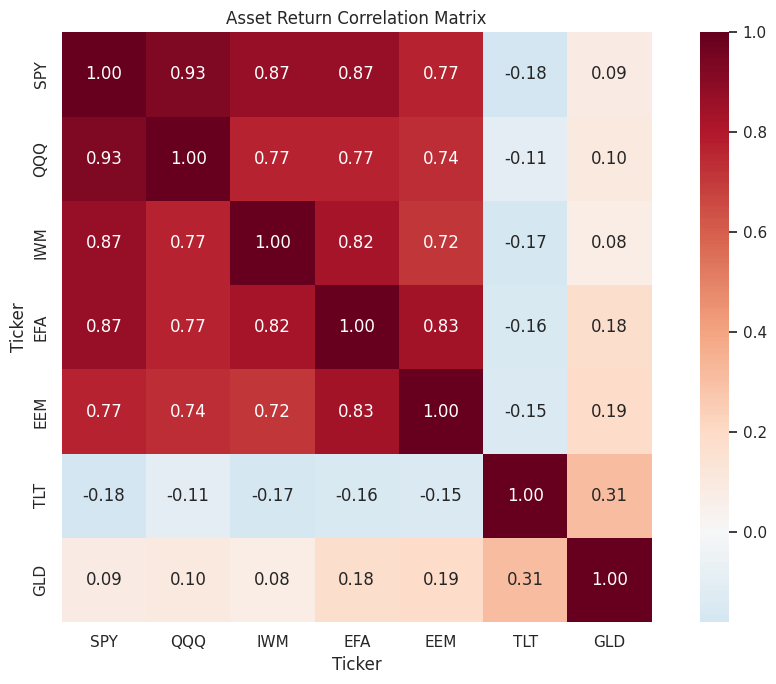

In [11]:
# Colab Cell 10 — Allocation and correlation charts
allocation_long = (
    weights_table.reset_index(names='Asset')
    .melt(id_vars='Asset', var_name='Portfolio', value_name='Weight')
)
fig = px.bar(
    allocation_long,
    x='Asset', y='Weight', color='Portfolio', barmode='group',
    title='Optimized Portfolio Allocations', template='plotly_white'
)
fig.update_yaxes(tickformat='.0%')
fig.show()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Asset Return Correlation Matrix')
plt.tight_layout()
plt.show()


## 13. Out-of-Sample Backtest

In [12]:
# Colab Cell 11 — Backtest optimized allocations on unseen data

def annualized_metrics(daily_returns: pd.Series, rf: float) -> Dict[str, float]:
    daily_returns = daily_returns.dropna()
    if daily_returns.empty:
        raise ValueError('Cannot evaluate an empty return series.')

    ann_return = (1 + daily_returns).prod() ** (TRADING_DAYS / len(daily_returns)) - 1
    ann_vol = daily_returns.std(ddof=1) * np.sqrt(TRADING_DAYS)
    downside = daily_returns[daily_returns < 0].std(ddof=1) * np.sqrt(TRADING_DAYS)
    wealth = (1 + daily_returns).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    max_drawdown = drawdown.min()
    sharpe = (ann_return - rf) / ann_vol if ann_vol > 0 else np.nan
    sortino = (ann_return - rf) / downside if downside and downside > 0 else np.nan
    calmar = ann_return / abs(max_drawdown) if max_drawdown < 0 else np.nan

    return {
        'Annualized Return': ann_return,
        'Annualized Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Maximum Drawdown': max_drawdown,
        'Calmar Ratio': calmar,
    }

cost_rate = CONFIG.transaction_cost_bps / 10000
initial_equal_weights = np.repeat(1 / len(CONFIG.tickers), len(CONFIG.tickers))
turnover_max_sharpe = np.abs(max_sharpe_weights - initial_equal_weights).sum()
turnover_min_vol = np.abs(min_vol_weights - initial_equal_weights).sum()

max_sharpe_test = test_returns @ max_sharpe_weights
min_vol_test = test_returns @ min_vol_weights
equal_weight_test = test_returns.mean(axis=1)

# Apply one-time rebalancing cost on the first test observation.
max_sharpe_test.iloc[0] -= turnover_max_sharpe * cost_rate
min_vol_test.iloc[0] -= turnover_min_vol * cost_rate

common_index = test_returns.index.intersection(benchmark_returns.index)
benchmark_test = benchmark_returns.reindex(common_index).dropna()

strategy_returns = pd.DataFrame({
    'Maximum Sharpe': max_sharpe_test.reindex(common_index),
    'Minimum Volatility': min_vol_test.reindex(common_index),
    'Equal Weight': equal_weight_test.reindex(common_index),
    f'Benchmark ({CONFIG.benchmark})': benchmark_test,
}).dropna()

backtest_metrics = pd.DataFrame({
    name: annualized_metrics(series, CONFIG.risk_free_rate)
    for name, series in strategy_returns.items()
}).T

display(backtest_metrics.style.format({
    'Annualized Return': '{:.2%}',
    'Annualized Volatility': '{:.2%}',
    'Sharpe Ratio': '{:.2f}',
    'Sortino Ratio': '{:.2f}',
    'Maximum Drawdown': '{:.2%}',
    'Calmar Ratio': '{:.2f}',
}))


,Annualized Return,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Maximum Drawdown,Calmar Ratio
Maximum Sharpe,24.52%,14.72%,1.39,1.82,-13.55%,1.81
Minimum Volatility,15.00%,10.95%,1.00,1.41,-9.95%,1.51
Equal Weight,17.85%,13.35%,1.04,1.42,-12.76%,1.40
Benchmark (SPY),19.22%,15.26%,1.00,1.26,-18.76%,1.02


In [13]:
# Colab Cell 12 — Cumulative returns and drawdowns
cumulative = (1 + strategy_returns).cumprod()
fig = px.line(
    cumulative,
    title='Out-of-Sample Growth of $1',
    labels={'value': 'Portfolio Value', 'index': 'Date', 'variable': 'Strategy'},
    template='plotly_white',
)
fig.show()

drawdowns = cumulative.div(cumulative.cummax()).sub(1)
fig = px.line(
    drawdowns,
    title='Out-of-Sample Drawdowns',
    labels={'value': 'Drawdown', 'index': 'Date', 'variable': 'Strategy'},
    template='plotly_white',
)
fig.update_yaxes(tickformat='.0%')
fig.show()


## 14. Performance Metrics

The project reports:

- Annualized return and volatility
- Sharpe, Sortino, and Calmar ratios
- Maximum drawdown
- Concentration and effective number of holdings
- Portfolio turnover and transaction-cost impact
- Out-of-sample comparison against equal weight and a benchmark


## 15. Export Final Deliverables

In [14]:
# Colab Cell 13 — Export tables for GitHub or downstream analysis
from pathlib import Path

EXPORT_DIR = Path('portfolio_optimizer_outputs')
EXPORT_DIR.mkdir(exist_ok=True)

weights_table.to_csv(EXPORT_DIR / 'optimized_weights.csv')
portfolio_stats.to_csv(EXPORT_DIR / 'portfolio_statistics.csv')
backtest_metrics.to_csv(EXPORT_DIR / 'backtest_metrics.csv')
frontier.drop(columns='Weights').to_csv(EXPORT_DIR / 'efficient_frontier.csv', index=False)

print(f'Exported project outputs to: {EXPORT_DIR.resolve()}')


Exported project outputs to: /content/portfolio_optimizer_outputs


## 16. Final Deliverables

- Colab-ready notebook
- Reusable optimization functions
- Cleaned price and return pipeline
- Efficient-frontier model
- Minimum-volatility and maximum-Sharpe allocations
- Out-of-sample backtest
- CSV exports
- Professional interactive charts
- GitHub README and requirements file

## Resume Description

**Quantitative Portfolio Optimization Project — Python, SciPy, pandas, scikit-learn, Plotly**  
Built a constrained multi-asset portfolio optimizer using Modern Portfolio Theory, Ledoit-Wolf covariance shrinkage, Monte Carlo simulation, and SLSQP optimization. Constructed the efficient frontier, identified maximum-Sharpe and minimum-volatility portfolios, and evaluated out-of-sample performance against equal-weight and market benchmarks using Sharpe, Sortino, Calmar, turnover, and drawdown metrics.

## Potential Upgrades

- Black-Litterman expected-return model
- Factor exposure and factor-neutral constraints
- Rolling or expanding-window rebalancing
- Transaction-cost optimization
- Risk-parity and hierarchical risk parity
- CVaR and downside-risk optimization
- Bayesian return forecasts
- Regime detection
- Streamlit dashboard
- Cloud deployment and scheduled data refreshes
